# Load diffuser

In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
from diffusers import UNet2DModel, DDPMScheduler

scheduler = DDPMScheduler.from_pretrained("google/ddpm-celebahq-256", use_safetensors = True)
pretrained_model = UNet2DModel.from_pretrained("google/ddpm-celebahq-256")

# By disabling the clipping, the mean of the distribution used by the scheduler will match exactly the predicted_mean
scheduler.config["clip_sample"] = False
scheduler = DDPMScheduler.from_config(scheduler.config)

pretrained_model = pretrained_model.to(device)

/home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [14]:
# Clear CUDA memory to avoid out of memory errors
import torch
import gc

# Empty the cache
torch.cuda.empty_cache()

# Perform garbage collection
gc.collect()

print("CUDA memory cleared")

# Optional: Print memory stats to verify
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"Memory allocated: {torch.cuda.memory_allocated(device) / 1024**2:.2f} MB")
    print(f"Memory reserved: {torch.cuda.memory_reserved(device) / 1024**2:.2f} MB")
    print(f"Max memory allocated: {torch.cuda.max_memory_allocated(device) / 1024**2:.2f} MB")


: 

In [15]:
quit()

# Helper functions

In [3]:
import PIL.Image
import numpy as np

def display_sample(sample, label = ""):
  image_processed = sample.cpu().permute(0, 2, 3, 1)
  image_processed = (image_processed + 1.0) * 127.5
  image_processed = image_processed.numpy().astype(np.uint8)
  image = PIL.Image.fromarray(image_processed[0])
  display(label)
  display(image)

In [4]:
def get_gradient_norm(model):
    total_norm = 0.0
    for param in model.parameters():
        if param.grad is not None:
            param_norm = param.grad.detach().data.norm(2)  # L2 norm
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5  # Square root to get final norm


# Diffusion trajectory classes

In [5]:
import torch
from torch import Tensor
from torch.distributions import Normal
from typing import List, Iterator, Optional
from diffusers import DDPMScheduler
from dataclasses import dataclass


@dataclass
class DiffusionStep:
    """Represents a single step in the diffusion trajectory.

    Attributes:
        timestep: The timestep index in the diffusion process
        current_sample: The noisy latent at this timestep (Xt)
        prev_sample: The previous sample in the trajectory (Xt-1)
        pred_noise: The predicted noise at this timestep (from original model)
        log_prob: The log probability of this step (from original model)
    """
    timestep: int
    current_sample: Tensor
    prev_sample: Tensor
    pred_noise: Tensor
    log_prob: Tensor
    mean: Tensor
    variance: Tensor

    def compute_log_prob(self, model, scheduler) -> Tensor:
        """Compute log probability using a different model with the same trajectory data.

        Args:
            model: The updated diffusion model
            scheduler: The noise scheduler

        Returns:
            Tensor: Updated log probability for this step
        """
        # Get device
        device = next(model.parameters()).device

        # Get model prediction for the noise
        current_sample = self.current_sample.detach()
        prev_sample = self.prev_sample.detach()

        residual = model(current_sample, self.timestep).sample

        # Get the distribution parameters for p(Xt-1 | Xt)
        t = self.timestep

        # Find the index of the current timestep in the scheduler's timesteps
        timestep_idx = scheduler.timesteps.tolist().index(t)
        last = timestep_idx == len(scheduler.timesteps) - 1

        if last:
            log_prob = torch.tensor([0.0]).to(device)
            predicted_mean = current_sample
            variance = torch.tensor([0.0]).to(device)
        else:
            # Get the next timestep in the sequence (if it exists)
            prev_timestep = scheduler.timesteps[timestep_idx + 1] 

            # Get the alpha and beta values for the current and previous timesteps
            alpha_prod_t = scheduler.alphas_cumprod[t].to(device)
            alpha_prod_t_prev = scheduler.alphas_cumprod[prev_timestep].to(device)
            beta_prod_t = 1 - alpha_prod_t
            beta_prod_t_prev = 1 - alpha_prod_t_prev
            
            # Calculate effective single-step alpha and beta
            current_alpha_t = alpha_prod_t / alpha_prod_t_prev
            current_beta_t = 1 - current_alpha_t

            # Calculate predicted mean
            pred_x0 = (current_sample - (beta_prod_t.sqrt()) * residual) / alpha_prod_t.sqrt()
            coeff_x0   = (alpha_prod_t_prev.sqrt() * current_beta_t) / beta_prod_t
            coeff_xt   = (current_alpha_t.sqrt() * beta_prod_t_prev) / beta_prod_t
            predicted_mean  = coeff_x0 * pred_x0 + coeff_xt * current_sample
            

            # Calculate variance
            variance = (1 - alpha_prod_t_prev) / (1 - alpha_prod_t) * current_beta_t 


            # Sum over all dimensions except batch
            dist = Normal(predicted_mean, torch.sqrt(variance))
            log_prob = dist.log_prob(prev_sample)
            log_prob = log_prob.mean(dim=list(range(1, len(log_prob.shape))))


            # Do the old way to compare
            old_mean = (1.0 / torch.sqrt(current_alpha_t)) * (
                current_sample - (current_beta_t / torch.sqrt(1.0 - alpha_prod_t)) * residual
            )
            old_log_prob = Normal(old_mean, torch.sqrt(variance)).log_prob(prev_sample).mean(dim=list(range(1, len(log_prob.shape))))

            # Check if the old and new log probability calculations are significantly different
            if not torch.allclose(old_log_prob, log_prob, rtol=1e-5, atol=1e-5):
                diff = torch.abs(old_log_prob - log_prob)
                raise ValueError(f"Log probability calculations differ: old={old_log_prob.item()}, new={log_prob.item()}, diff={diff.item()}. This may indicate precision errors in the implementation.")

        return log_prob, predicted_mean, variance



class Trajectory:
    """Represents a full diffusion trajectory from noise to image.

    This class allows iteration over diffusion steps and supports re-computation
    of log probabilities with updated models without re-sampling the trajectory.
    """

    def __init__(
        self,
        model,
        scheduler: DDPMScheduler,
        device: torch.device,
        num_inference_steps: Optional[int] = None,
        starting_noise: Optional[Tensor] = None
    ):
        """Initialize and generate a diffusion trajectory.

        Args:
            model: The diffusion model used to generate the trajectory
            scheduler: The noise scheduler
            device: The device to use for computation
            num_inference_steps: Optional number of inference steps
            starting_noise: Optional pre-defined noise to start from
        """
        self.model = model
        self.scheduler = scheduler
        self.device = device

        # Use provided number of timesteps or default to scheduler
        self.num_inference_steps = num_inference_steps or scheduler.config.num_train_timesteps // 50

        # Generate or use provided starting noise
        if starting_noise is None:
            latent_shape = (1, model.config.in_channels, model.config.sample_size, model.config.sample_size)
            self.starting_noise = torch.randn(latent_shape, device=device)
        else:
            self.starting_noise = starting_noise.to(device)

        # Generate the trajectory
        self.steps = self._generate_trajectory()

    def _generate_trajectory(self) -> List[DiffusionStep]:
        """Generate the complete diffusion trajectory.

        Returns:
            List[DiffusionStep]: A list of diffusion steps from noise to image
        """
        steps = []

        # Initialize the scheduler and start with pure noise
        self.scheduler.set_timesteps(self.num_inference_steps)
        latent = self.starting_noise.clone() 

        # Generate trajectory by iterating through the diffusion process
        for i, t in enumerate(self.scheduler.timesteps):
            # Get model prediction
            with torch.no_grad():
                pred_noise = self.model(latent, t).sample

            # Step the scheduler to get the next latent
            scheduler_output = self.scheduler.step(pred_noise, t, latent)
            prev_sample = scheduler_output.prev_sample

            # Create step
            step = DiffusionStep(
                timestep=t,
                current_sample=latent.clone(),  # Current latent (Xt)
                prev_sample=prev_sample.clone(),  # Next latent in the trajectory (Xt-1)
                pred_noise=pred_noise,
                log_prob=None,
                mean=None,
                variance=None
            )
            steps.append(step)

            # Compute log probability
            step.log_prob, step.mean, step.variance = step.compute_log_prob(self.model, self.scheduler)
            step.log_prob = step.log_prob.detach()
            step.mean = step.mean.detach()
            step.variance = step.variance.detach()

            # Move to the next step
            latent = prev_sample

        return steps

    def __iter__(self) -> Iterator[DiffusionStep]:
        """Allow iteration over trajectory steps."""
        return iter(self.steps)

    def __len__(self) -> int:
        """Return the number of steps in the trajectory."""
        return len(self.steps)

    def __getitem__(self, idx) -> DiffusionStep:
        """Get a specific step by index."""
        return self.steps[idx]

# Reward model

In [6]:
from transformers import pipeline, logging
logging.set_verbosity_error()

def gender_reward(img_tensor):

  pipe = pipeline("image-classification", model="rizvandwiki/gender-classification")

  image_processed = img_tensor.cpu().permute(0, 2, 3, 1)
  image_processed = (image_processed + 1.0) * 127.5
  image_processed = image_processed.numpy().astype(np.uint8)
  image = PIL.Image.fromarray(image_processed[0])

  classification = pipe(image)
  for class_pred in classification:
    if class_pred["label"] == "male":
      if class_pred["score"] >= 0.8 or class_pred["score"] <= 0.2:
        return class_pred["score"]
      else:
        return 0.0

# Analyze trajectories

In [ ]:
trajectories_val = []
total_reward = 0
for i in range(1):
    trajectories_val.append(Trajectory(pretrained_model, scheduler, device, num_inference_steps=50))
    reward = gender_reward(trajectories_val[-1][-1].prev_sample)
    total_reward += reward
    for i, step in enumerate(trajectories_val[-1][20:]):
      if i % 100 == 0:
        display_sample(step.prev_sample, label=f"Timestep: {step.timestep}, {step.log_prob}, {step.variance}")

In [9]:
quit()

# Fine-tune with REINFORCE

## Generate dataset function

In [7]:
def generate_dataset(model, scheduler, device, prompts, batch_size, group_size):
    """
    The final dataset will have (prompts x group_size) trajectories.
    The shape will be (n_batches, batch_size (same as n_groups_per_batch), group_size).
    The last batch can have fewer groups if the number of prompts is not divisible by batch_size.
    """
    steps_dataset = []

    # Iterate over prompts in chunks of batch_size
    for i in range(0, len(prompts), batch_size):
        batch = []
        for prompt in prompts[i:i + batch_size]:
            group = [Trajectory(model, scheduler, device, num_inference_steps=50) for _ in range(group_size)]
            batch.append(group)
        steps_dataset.append(batch)

    return steps_dataset


## Generate validation dataset

In [ ]:
# Generate validation dataset once before training
print(f"{20*'-*'} Generating validation dataset {40*'-*'}")
validation_trajectories = generate_dataset(model=pretrained_model,
                                     scheduler=scheduler,
                                     device=device,
                                     prompts = 40*[None],
                                     batch_size=1,
                                     group_size=1)
# Flatten the validation dataset into a list of trajectories
validation_trajectories = [trajectory for batch in validation_trajectories for group in batch for trajectory in group]

# Evaluate trajectories and label them as "male" or "female" based on reward
validation_labels = []
male_trajectories = []
female_trajectories = []

for trajectory in validation_trajectories:
    reward = gender_reward(trajectory[-1].prev_sample)
    label = "male" if reward > 0.5 else "female"
    
    if label == "male":
        male_trajectories.append((trajectory, label))
        display_sample(trajectory[-1].prev_sample, label=f"Label = {label}")
    else:
        female_trajectories.append((trajectory, label))

# Count males and select equal number of females
num_males = len(male_trajectories)
female_trajectories = female_trajectories[:num_males]  # Take only as many females as males

# Display the selected females
for trajectory, label in female_trajectories:
    display_sample(trajectory[-1].prev_sample, label=f"Label = {label}")

# Combine male and female trajectories for balanced dataset
validation_dataset = male_trajectories + female_trajectories

In [ ]:
del validation_trajectories, male_trajectories, female_trajectories

## Train

In [8]:
import pandas as pd

def train_with_reinforce(model,
                         dataset,
                         train_epochs=5,
                         lr=1e-6,
                         initial_step=None,
                         final_step=None,
                         alpha=1.0,
                         beta=0.0,
                         max_grad_norm=1.0,
                         validation_dataset=None):
    """
    Train a diffusion model using REINFORCE algorithm with PPO-style clipping.
    
    Args:
        model: The diffusion model to train
        dataset: Dataset of trajectories organized as [batch][group][trajectory]
        train_epochs: Number of training epochs over the dataset
        lr: Learning rate for optimizer
        initial_step: First denoising step to train on (default: 0)
        final_step: Last denoising step to train on (default: -1)
        alpha: Weight for the clipping loss
        beta: Weight for the KL regularization
        max_grad_norm: Maximum gradient norm for gradient clipping. If <= 0, no gradient clipping is applied.
        validation_dataset: Dataset of validation trajectories for evaluation
    Returns:
        updated_model: The trained model
        log_df: DataFrame containing training metrics
    """
    # Set default values for the range of denoising steps to train on
    initial_step = 0 if initial_step is None else initial_step
    final_step = -1 if final_step is None else final_step

    # Prepare model and optimizer
    updated_model = model
    updated_model.train()
    optimizer = torch.optim.AdamW(updated_model.parameters(), lr=lr)

    # Logging data
    log_data = []

    # Training loop
    for epoch in range(train_epochs):
        total_loss = 0
        total_reward = 0
        total_loss_positive_advantage = 0
        total_loss_negative_advantage = 0
        count_positive_advantage = 0
        count_negative_advantage = 0
        
        for batch_idx, batch in enumerate(dataset):
            n_trajectories = len(batch) * len(batch[0])
            
            for group_idx, group in enumerate(batch):
                trajectories = group
                
                # Calculate rewards for each trajectory in the group
                rewards = [gender_reward(trajectory[-1].prev_sample) for trajectory in trajectories]
                #print("Rewards: ", rewards)
                total_reward += sum(rewards)
                
                # Skip groups with no high-reward samples
                if max(rewards) < 0.5:  # No men
                    print("Skipping group")
                    n_trajectories -= len(group)
                    continue

                # Normalize advantages within the group
                group_mean = torch.tensor(rewards).mean()
                group_std = torch.tensor(rewards).std() + 1e-5
                advantages = [(reward - group_mean) / group_std for reward in rewards]
                print("Advantages: ", advantages)

                # Process each trajectory in the group
                for i, trajectory in enumerate(trajectories):
                    sample_prob = 0.0
                    
                    # Process each step in the trajectory
                    for step_idx, step in enumerate(trajectory[initial_step:final_step]):
                        # Compute log probability with the updated model
                        log_prob_new, mean, var = step.compute_log_prob(updated_model, trajectory.scheduler)

                        # Importance Sampling Ratio
                        importance_ratio = torch.exp(log_prob_new - step.log_prob)

                        # Get advantage for this trajectory
                        advantage = advantages[i]

                        # PPO clipping
                        clipped_ratio = torch.clamp(importance_ratio, 1 - 1e-4, 1 + 1e-4)
                        loss_clip = torch.min(importance_ratio * advantage, clipped_ratio * advantage)

                        # KL regularization between old and new distributions
                        kl = torch.distributions.kl_divergence(
                            torch.distributions.Normal(step.mean, torch.sqrt(step.variance)),
                            torch.distributions.Normal(mean, torch.sqrt(var))
                        )
                        kl = kl.mean(dim=list(range(1, len(kl.shape))))

                        # Compute the total loss
                        loss_base = -alpha * loss_clip + beta * kl
                        loss_total = loss_base.view(loss_base.size(0), -1).sum(dim=1).mean()
                        
                        # Average across trajectories
                        loss_total = loss_total / n_trajectories
                        
                        # Store current gradients before backward pass
                        prev_grads = [p.grad.clone() if p.grad is not None else None 
                                    for p in updated_model.parameters()]
                        
                        # Backward pass
                        loss_total.backward()
                        sample_prob += log_prob_new.item()

                        # Calculate gradient norm for this step only
                        current_grad_norm = 0
                        for idx, p in enumerate(updated_model.parameters()):
                            if p.grad is not None:
                                # Subtract previous gradient if it existed
                                if prev_grads[idx] is not None:
                                    step_grad = p.grad - prev_grads[idx]
                                else:
                                    step_grad = p.grad
                                current_grad_norm += step_grad.norm().item() ** 2
                        current_grad_norm = current_grad_norm ** 0.5

                        # Log metrics for this step
                        log_data.append({
                            "epoch": epoch,
                            "batch": batch_idx,
                            "group": group_idx,
                            "sample": i,
                            "step": step_idx,
                            "log_prob_new": log_prob_new.item(),
                            "log_prob_old": step.log_prob.item(),
                            "importance_ratio": importance_ratio.item(),
                            "clipped_ratio": clipped_ratio.item(),
                            "kl_loss": kl.item(),
                            "reward": rewards[i],
                            "advantage": advantage.item(),
                            "loss_clip": loss_clip.item(),
                            "loss_base": loss_base.item(),
                            "loss_total": loss_total.item(),
                            "gradient": current_grad_norm,
                            "running_gradient": get_gradient_norm(updated_model)
                        })

                    total_loss += sample_prob
                    
                    
                    # Track loss for positive and negative advantage samples
                    if advantage > 0:
                        total_loss_positive_advantage += sample_prob
                        count_positive_advantage += 1
                    else:
                        total_loss_negative_advantage += sample_prob
                        count_negative_advantage += 1

            # Update the model parameters
            if max_grad_norm > 0:
              old_grad_norm = torch.nn.utils.clip_grad_norm_(updated_model.parameters(), max_norm=max_grad_norm)
              print(f"Old grad norm: {old_grad_norm} | Running loss: {total_loss}")
            optimizer.step()
            optimizer.zero_grad()
            
        
        # Evaluate the model on the validation dataset
        if validation_dataset is not None:
            print("Evaluating model on validation dataset...")
            male_log_probs = []
            female_log_probs = []
            
            for trajectory, label in validation_dataset:
                # Compute log probability for each step in the trajectory
                trajectory_log_prob = 0.0
                for step in trajectory:
                    with torch.no_grad():
                        # Get the log probability of this step using the updated model
                        log_prob_new, mean, var = step.compute_log_prob(updated_model, trajectory.scheduler)
                        trajectory_log_prob += log_prob_new.item()
                
                # Add to the appropriate list based on the label
                if label == "male":
                    male_log_probs.append(trajectory_log_prob)
                elif label == "female":
                    female_log_probs.append(trajectory_log_prob)
            
            # Calculate average log probabilities
            avg_male_log_prob = sum(male_log_probs) / len(male_log_probs) if male_log_probs else 0
            avg_female_log_prob = sum(female_log_probs) / len(female_log_probs) if female_log_probs else 0
            
            print(f"Validation results - Avg male log prob: {avg_male_log_prob:.4f} | Avg female log prob: {avg_female_log_prob:.4f}")
          
        print(f"Epoch reward: {total_reward} | Epoch loss: {total_loss/(count_positive_advantage+count_negative_advantage)} | Positive loss: {total_loss_positive_advantage/count_positive_advantage} | Negative loss: {total_loss_negative_advantage/count_negative_advantage}")

    # Convert log data to DataFrame
    log_df = pd.DataFrame(log_data)

    return updated_model, log_df


In [14]:
full_epochs = 10 # Each full epoch include sampling + training # 2/2
train_epochs = 2 # Specifies how many times the model iterates over the same sampled trajectories

In [ ]:
import copy
model = copy.deepcopy(pretrained_model).to(device)

dfs =[]
for i in range(full_epochs):
  # Generate dataset of trajectories (n_batches, n_groups_per_batch (batch_size), group_size)
  print(f"{20*'-*'} Full epoch {i} {20*'-*'}")
  dataset = generate_dataset(model=model,
                             scheduler=scheduler,
                             device=device,
                             prompts = 5*[None],
                             batch_size=1,
                             group_size=5)
  model, df = train_with_reinforce(model, dataset, train_epochs, lr=1e-6, max_grad_norm=1.0, initial_step=22, final_step=47, validation_dataset=None)#validation_dataset)
  dfs.append(df)

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* Full epoch 0 -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*


Advantages:  [tensor(-0.4468), tensor(-0.4470), tensor(-0.4482), tensor(-0.4468), tensor(1.7888)]
Old grad norm: 0.057077113538980484 | Running loss: -20.544377490878105
Skipping group
Old grad norm: 0.0 | Running loss: -20.544377490878105
Advantages:  [tensor(-0.4544), tensor(-0.4495), tensor(-0.4271), tensor(1.7887), tensor(-0.4578)]
Old grad norm: 0.05383390933275223 | Running loss: -41.09112440980971
Skipping group
Old grad norm: 0.0 | Running loss: -41.09112440980971
Advantages:  [tensor(-0.4429), tensor(-0.4496), tensor(-0.4462), tensor(1.7888), tensor(-0.4501)]
Old grad norm: 0.055862512439489365 | Running loss: -61.63055866397917
Epoch reward: 3.257449139840901 | Epoch loss: -4.108703910931945 | Positive loss: -4.104732049629092 | Negative loss: -4.109696876257658
Advantages:  [tensor(-0.4468), tensor(-0.4470), tensor(-0.4482), tensor(-0.4468), tensor(1.7888)]
Old grad norm: 0.05259422957897186 | Running loss: -20.544563310220838
Skipping group
Old grad norm: 0.0 | Running loss

## Save

In [11]:
import datetime
import json

# Create a timestamp for the filename
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
base_filename = f"reinforce_log_{timestamp}"
csv_filename = f"{base_filename}.csv"
config_filename = f"{base_filename}_config.json"

# Add sampling epoch to each dataframe
for i in range(len(dfs)):
  dfs[i]["sampling_epoch"] = i

# Concatenate all dataframes and save to CSV
concated_df = pd.concat(dfs)
concated_df.to_csv(f"experiments/{csv_filename}")

# Create and save a config file with the same base name
config = {
    "full_epochs": full_epochs,
    "train_epochs": train_epochs,
    "learning_rate": 1e-6,
    "prompts_per_batch": 5,
    "batch_size": 1,
    "group_size": 5,
    "initial_step": 22,
    "final_step": 47,
    "timestamp": timestamp
}

with open(f"experiments/{config_filename}", 'w') as f:
    json.dump(config, f, indent=4)

print(f"Saved data to {csv_filename} and config to {config_filename}")

Batch 0
Sample 0


''

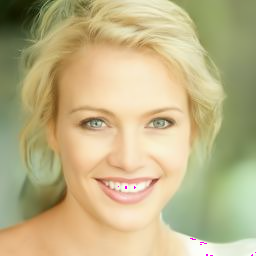

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_0_group_0_sample_0.png
Sample 1


''

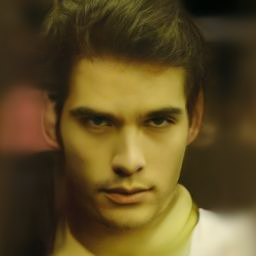

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_0_group_0_sample_1.png
Sample 2


''

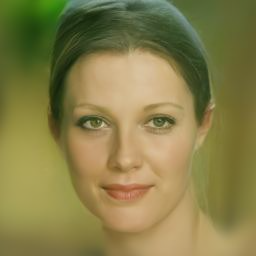

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_0_group_0_sample_2.png
Sample 3


''

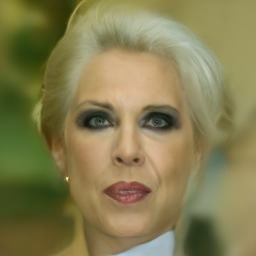

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_0_group_0_sample_3.png
Sample 4


''

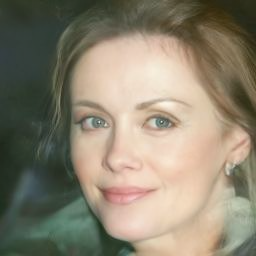

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_0_group_0_sample_4.png
Batch 1
Sample 0


''

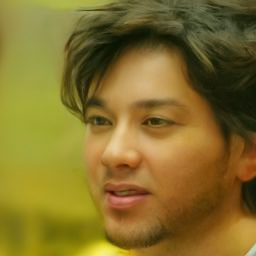

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_1_group_0_sample_0.png
Sample 1


''

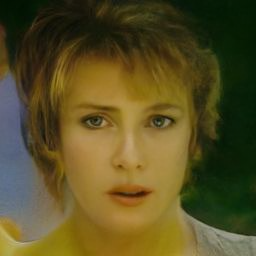

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_1_group_0_sample_1.png
Sample 2


''

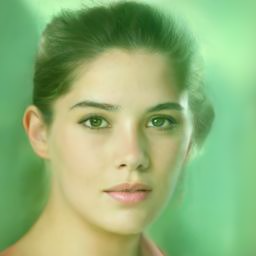

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_1_group_0_sample_2.png
Sample 3


''

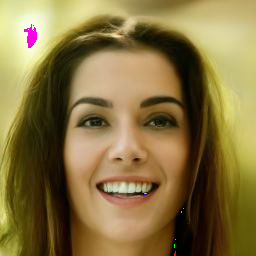

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_1_group_0_sample_3.png
Sample 4


''

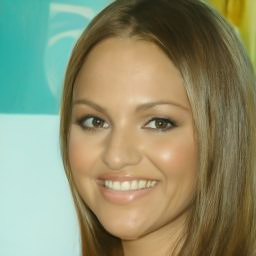

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_1_group_0_sample_4.png
Batch 2
Sample 0


''

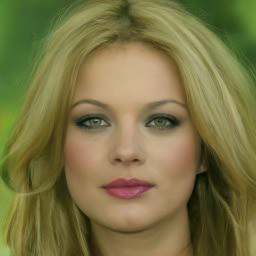

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_2_group_0_sample_0.png
Sample 1


''

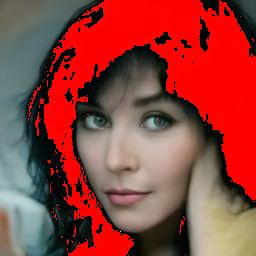

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_2_group_0_sample_1.png
Sample 2


''

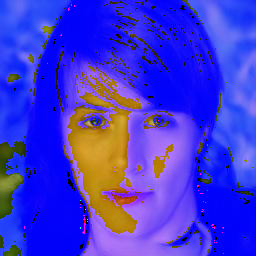

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_2_group_0_sample_2.png
Sample 3


''

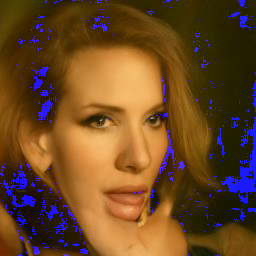

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_2_group_0_sample_3.png
Sample 4


''

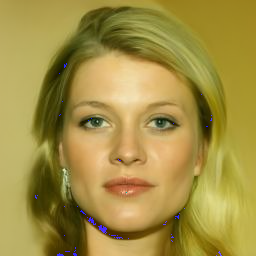

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_2_group_0_sample_4.png
Batch 3
Sample 0


''

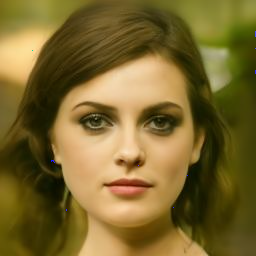

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_3_group_0_sample_0.png
Sample 1


''

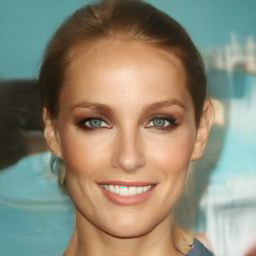

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_3_group_0_sample_1.png
Sample 2


''

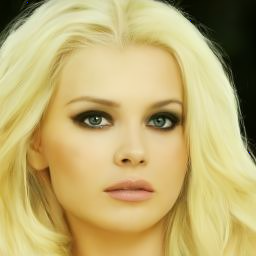

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_3_group_0_sample_2.png
Sample 3


''

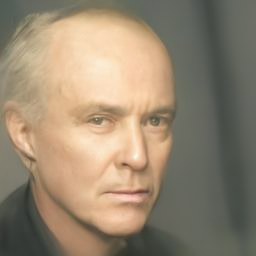

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_3_group_0_sample_3.png
Sample 4


''

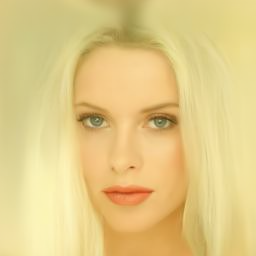

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_3_group_0_sample_4.png
Batch 4
Sample 0


''

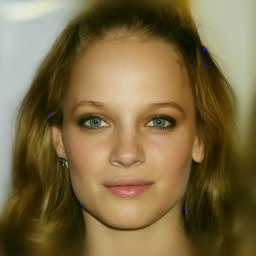

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_4_group_0_sample_0.png
Sample 1


''

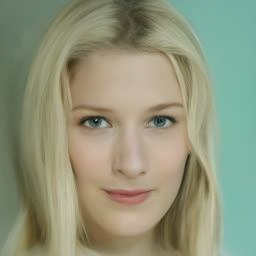

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_4_group_0_sample_1.png
Sample 2


''

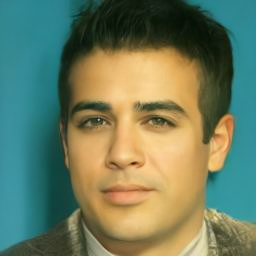

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_4_group_0_sample_2.png
Sample 3


''

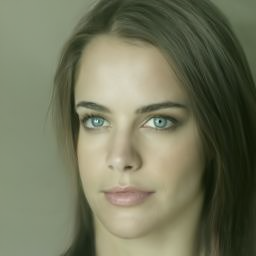

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_4_group_0_sample_3.png
Sample 4


''

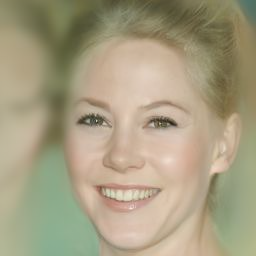

Saved to reinforce_log_1_sampling_40_epochs_5_prompts_all_steps_no_grad_clip_lr_1e-6_v2/batch_4_group_0_sample_4.png


In [13]:
import os
from PIL import Image

# Create a directory based on the filename (without extension)
save_dir = os.path.splitext(filename)[0]
os.makedirs(save_dir, exist_ok=True)

for b, batch in enumerate(dataset):
    print(f"Batch {b}")
    for g, group in enumerate(batch):
        for s, sample in enumerate(group):
            print(f"Sample {s}")
            # Get the image
            img = sample[-1].prev_sample
            # Display the image
            display_sample(img)
            # Save the image
            # Fix the permute dimensions to match the tensor's dimensions (which is 4D)
            # The tensor likely has shape [batch, channels, height, width]
            img_np = img.cpu().squeeze(0).permute(1, 2, 0).numpy()  # Remove batch dimension if present
            img_pil = Image.fromarray(((img_np + 1.0) * 127.5).astype(np.uint8))
            img_path = os.path.join(save_dir, f"batch_{b}_group_{g}_sample_{s}.png")
            img_pil.save(img_path)
            print(f"Saved to {img_path}")

In [ ]:
# Save the fine-tuned model
import os

# Create a directory for saving models if it doesn't exist
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

# Save the model state dictionary
model_save_path = os.path.join(save_dir, "fine_tuned_diffusion_model.pt")
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# Optionally, save the entire model pipeline
model_pipeline_path = os.path.join(save_dir, "fine_tuned_diffusion_pipeline")
model.save_pretrained(model_pipeline_path)
print(f"Model pipeline saved to {model_pipeline_path}")


## Analyze results

'Reward = 0.0'

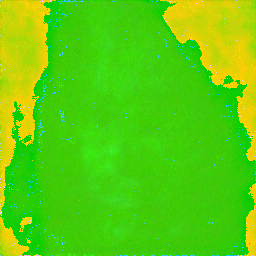

'Reward = 0.0'

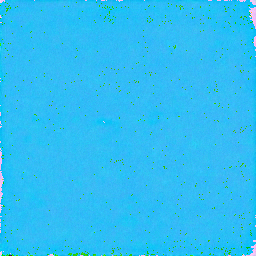

'Reward = 0.0'

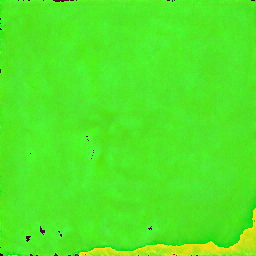

'Reward = 0.0'

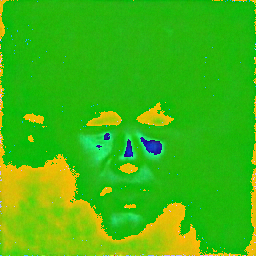

'Reward = 0.0'

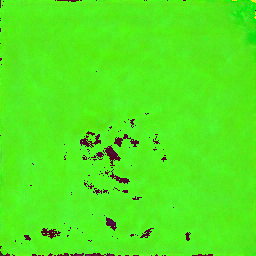

'Reward = 0.0'

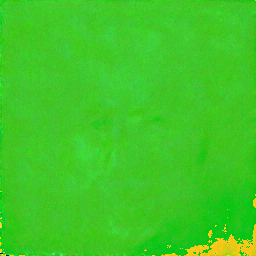

'Reward = 0.0'

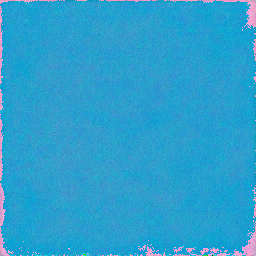

'Reward = 0.0'

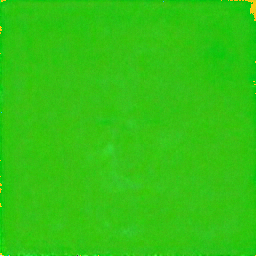

'Reward = 0.0'

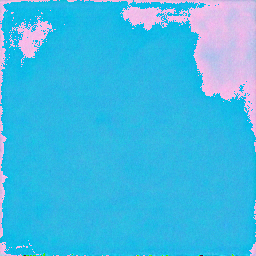

'Reward = 0.0'

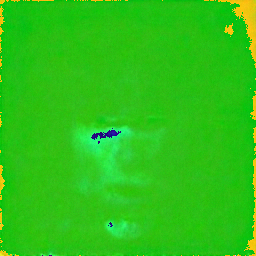

'Reward = 0.0'

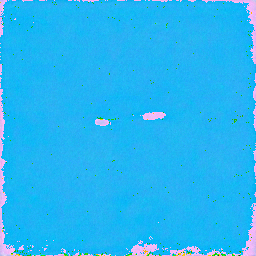

'Reward = 0.0875372514128685'

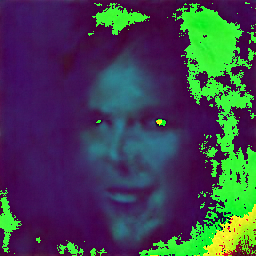

'Reward = 0.0'

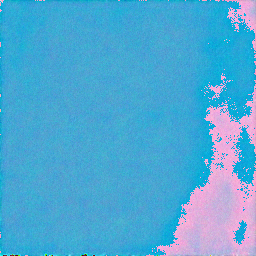

'Reward = 0.0'

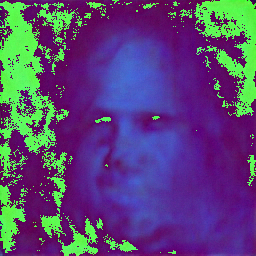

'Reward = 0.0'

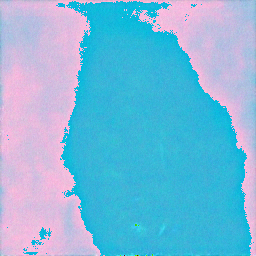

'Reward = 0.0'

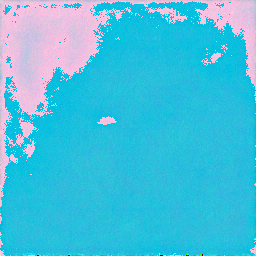

'Reward = 0.0'

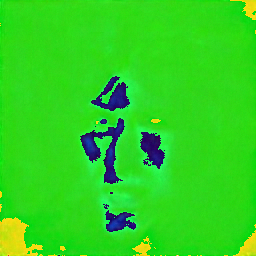

'Reward = 0.0'

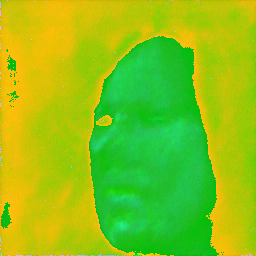

'Reward = 0.0'

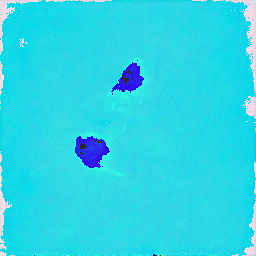

'Reward = 0.0'

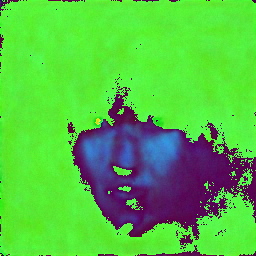

Total reward: 0.0875372514128685


In [12]:
total_reward = 0
for _ in range(20):
  trajectorie = Trajectory(model, scheduler, device, num_inference_steps=50)
  reward = gender_reward(trajectorie[-1].prev_sample)
  total_reward += reward
  display_sample(trajectorie[-1].prev_sample, label=f"Reward = {reward}")
print(f"Total reward: {total_reward}")

In [ ]:
total_reward = 0
for _ in range(20):
  trajectorie_ref = Trajectory(pretrained_model, scheduler, device, num_inference_steps=50)
  reward = gender_reward(trajectorie_ref[-1].prev_sample)
  total_reward += reward
  display_sample(trajectorie_ref[-1].prev_sample, label=f"Reward = {reward}")
print(f"Total reward: {total_reward}")